In [1]:
import math
import numpy as np 
import netCDF4 as nc
import xarray as xr
import thermofeel as tmf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import rioxarray
import glob
from datetime import datetime

import zipfile
import os
import shutil
import gc
import cdsapi

# Upload and prepare the data

In [2]:
# Collect all .nc file paths
nc_files = sorted(glob.glob(r"0_input/ERA5_grid_cell_data/output/025_alltemps_*.nc"))
# Open and concatenate along time
all_temps = {}
for f in nc_files:
    ds = xr.open_mfdataset(f, combine='by_coords').load()
    daily = ds.resample(time="1D").mean()
    all_temps[f]= daily
alltemps = xr.concat(all_temps.values(), dim='time')
print(alltemps)

<xarray.Dataset> Size: 611MB
Dimensions:  (time: 1218, lat: 117, lon: 119)
Coordinates:
    number   int64 8B 0
  * lat      (lat) float64 936B 35.5 35.25 35.0 34.75 34.5 ... 7.25 7.0 6.75 6.5
  * lon      (lon) float64 952B 68.0 68.25 68.5 68.75 ... 96.75 97.0 97.25 97.5
  * time     (time) datetime64[ns] 10kB 2014-10-01 2014-10-02 ... 2019-12-31
Data variables:
    t2m      (time, lat, lon) float32 68MB 286.3 286.9 288.0 ... 301.1 301.2
    rh       (time, lat, lon) float32 68MB 37.06 35.64 31.17 ... 77.11 76.7
    wbt      (time, lat, lon) float32 68MB 279.3 279.6 279.9 ... 297.9 297.9
    mrt      (time, lat, lon) float32 68MB 288.7 290.0 290.2 ... 308.0 308.0
    bgt      (time, lat, lon) float64 136MB 287.8 288.3 289.4 ... 302.4 302.4
    wbgt     (time, lat, lon) float64 136MB 281.7 282.1 282.6 ... 299.1 299.1
    tp       (time, lat, lon) float32 68MB 0.0 0.0 0.0 ... 2.65e-05 1.79e-05
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for

### create a new dimension : season. It will be very useful for graphs and maps after

In [3]:
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Kharif"
    elif month in [9, 10, 11]:
        return "Rabi"

# Apply function to each timestep
season = xr.DataArray(
    [assign_season(m) for m in alltemps['time'].dt.month.values],
    coords=[alltemps['time']],
    dims="time"
)

# Add season as a coordinate
alltemps = alltemps.assign_coords(season=season)

### celsuis conversion for better understanding

In [4]:
alltemps['t2m_c'] = alltemps['t2m']-273.15
alltemps['wbgt_c'] = alltemps['wbgt']-273.15

### Use a India shp to put a mask on the data. It puts to nan all the pixels that do not fall over the Indian territory (eg ocean, Nepal)

In [5]:
# Load India shapefile
india = gpd.read_file("0_input/district_borders/Census_2001/IND_adm0.shp")

# one DataArray for each variable
wbgt = alltemps['wbgt_c']
t2m = alltemps['t2m_c']
rh = alltemps['rh']

# Assign CRS if missing
wbgt.rio.write_crs("EPSG:4326", inplace=True)
t2m.rio.write_crs("EPSG:4326", inplace=True)
rh.rio.write_crs("EPSG:4326", inplace=True)

# Clip to India
wbgt = wbgt.rio.clip(india.geometry, india.crs)
t2m = t2m.rio.clip(india.geometry, india.crs)
rh = rh.rio.clip(india.geometry, india.crs)


#create a new xr.array object with the clipped data
two_temps = xr.merge([wbgt, t2m, rh])
#two_temps = two_temps.assign_coords(time=pd.to_datetime(two_temps.time.values))

### A general scatterplot

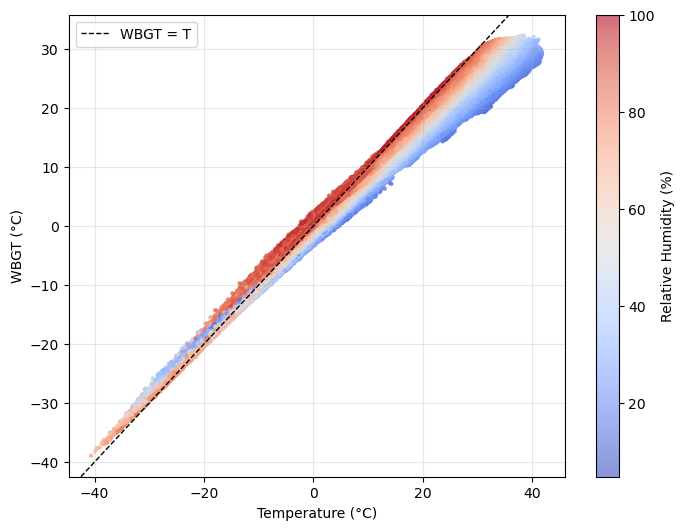

In [ ]:
# Flatten data to 1D arrays
x = t2m.values.ravel()
y = wbgt.values.ravel()
c = rh.values.ravel()   

plt.figure(figsize=(8, 6))
sc = plt.scatter(x, y, c=c, cmap="coolwarm", s=5, alpha=0.6)
line = plt.axline(xy1 = (0,0), slope = 1, color='black', linestyle='--', linewidth=1, label = "WBGT = T")

plt.colorbar(sc, label="Relative Humidity (%)")
plt.xlabel("Temperature (°C)")
plt.ylabel("WBGT (°C)")
plt.legend(loc = "upper left")
plt.grid(alpha=0.3)

plt.savefig("./3_output/img/wbgt_t2m_scatterplot.png", dpi=300)
plt.show()

### scatterplot with seasons

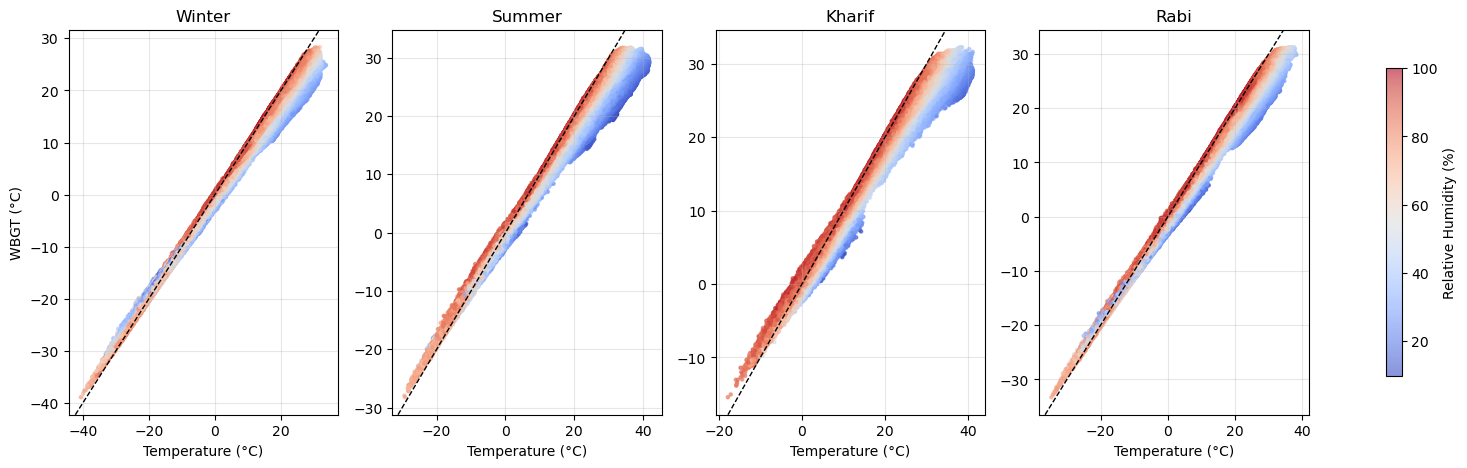

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for k, season in enumerate(['Winter', 'Summer', 'Kharif', 'Rabi']):
    seasonal_data = two_temps.sel(time=two_temps.season == season)
    # Flatten data to 1D arrays
    x = seasonal_data['t2m_c'].values.ravel()
    y = seasonal_data['wbgt_c'].values.ravel()
    c = seasonal_data['rh'].values.ravel()   

    sc = axes[k].scatter(x, y, c=c, cmap="coolwarm", s=5, alpha=0.6)
    line = axes[k].axline(xy1 = (0,0), slope = 1, color='black', linestyle='--', linewidth=1)
    axes[k].set_xlabel("Temperature (°C)")
    if k == 0: 
        axes[k].set_ylabel("WBGT (°C)")
    axes[k].set_title(season)
    axes[k].grid(alpha=0.3)

# colorbar for the whole figure
cbar = fig.colorbar(sc, ax=axes, label="Relative Humidity (%)", shrink=0.8)

#plt.tight_layout()
plt.savefig("./3_output/img/wbgt_t2m_scatterplot_season.png", dpi=300, bbox_inches="tight")
plt.show()